## 0. Imports / Constants

In [1]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import argparse
from tqdm import tqdm

#CAFPYANA working directory
CAFPYANA_WD = '/exp/sbnd/app/users/brindenc/develop/cafpyana'
os.environ['CAFPYANA_WD'] = CAFPYANA_WD

cafpyana_wd = os.environ.get('CAFPYANA_WD')
if cafpyana_wd and cafpyana_wd not in sys.path:
    sys.path.insert(0, cafpyana_wd)
    sys.path.insert(0, cafpyana_wd + '/pyanalib')

#My imports 
SBNDANA_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd'
WIENER_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/unfolding'
sys.path.insert(0,SBNDANA_DIR)
sys.path.insert(0,f'{SBNDANA_DIR.replace("/numuincl/sbnd","/numuincl")}')
sys.path.insert(0,WIENER_DIR)
plt.style.use(f'{SBNDANA_DIR}/plotlibrary/numu2025.mplstyle')


#My imports
from sbnd.cafclasses.slice import CAFSlice
from sbnd.cafclasses.interaction import CAFInteraction
from sbnd.cafclasses.nu import NU
from sbnd.constants import *
from sbnd.numu.numu_constants import *
from sbnd.detector.definitions import * # >= v2.2
from sbnd.general import plotters
from naming import *
from sbnd.general.utils import h5py_file_xrootd, read_hdf_xrootd

#Weiner imports
from wienersvd import *
from unfolding_inputs import *

%load_ext autoreload
%autoreload 2

In [2]:
from datetime import date
day = date.today().strftime("%Y_%m_%d")

DATA_DIR = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora'
PNFS_DATA_DIR = '/pnfs/sbnd/persistent/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora'
DET_VAR_DIR = os.path.join(DATA_DIR,'det_var')
PNFS_DET_VAR_DIR = os.path.join(PNFS_DATA_DIR,'det_var')
PLOT_DIR = f'{DATA_DIR}/plots/{day}/syst'
SAVE_DIR = f'{DATA_DIR}/data/{day}/syst'
os.makedirs(SAVE_DIR,exist_ok=True)


#CV sample with slim systematics
MC_SLIM_FNAME = f'{DATA_DIR}/mc_syst/v4/mc_tinypand_slimsyst_nocuts_norecomb.df'

#Nominal sample which contains calo variations
MC_NOMINAL_FNAME = f'{DET_VAR_DIR}/nominal/mc_nominal_nosyst_nocuts_recomb_small2.df'

#Calo variations, last index is nominal
CALO_SUFFIXES = ["_alpha_embm1", "_beta_90m1", "_R_embm1","_alpha_embp1", "_beta_90p1", "_R_embp1"]
CALO_VARS = [s[1:] for s in CALO_SUFFIXES]
CALO_VARS.pop(-1) #Remove nominal

#PDS variations
PDS_MC_BASE_FNAME = MC_NOMINAL_FNAME.split('/')[-1]
PDS_VARS = ['pmtgain','pmtqe','pmtspe']
PDS_FNAMES = [f'{DET_VAR_DIR}/pds/{PDS_MC_BASE_FNAME}'.replace('nominal',v).replace('2.df','.df') for v in PDS_VARS]

#SCE variations
SCE_MC_BASE_FNAME = MC_NOMINAL_FNAME.split('/')[-1]
SCE_VARS = ['nosce','twicesce']
SCE_FNAMES = [f'{DET_VAR_DIR}/sce/{SCE_MC_BASE_FNAME}'.replace('nominal',v).replace('2.df','.df').replace('small','med').replace('recomb','norecomb') for v in SCE_VARS]

#Wiremod variations
WIREMOD_MC_BASE_FNAME = MC_NOMINAL_FNAME.split('/')[-1]
WIREMOD_VARS = ['wiremodxtheta','wiremodyz']
WIREMOD_FNAMES = [f'{DET_VAR_DIR}/wiremod/{WIREMOD_MC_BASE_FNAME}'.replace('nominal',v).replace('2.df','.df').replace('small','med').replace('recomb','norecomb') for v in WIREMOD_VARS]

DET_VARS = PDS_VARS + SCE_VARS + WIREMOD_VARS
DET_FNAMES = PDS_FNAMES + SCE_FNAMES + WIREMOD_FNAMES

#Get supplemental files
OFFBEAM_FNAME = f'{DATA_DIR}/offbeam/v4/mc_medpand_nosyst_nocuts_recomb.df'
DATA_OFFBEAM_FNAME = f'{DATA_DIR}/offbeam/v4/data_small_nocuts.df'
DATA_FNAME = f'{DATA_DIR}/data/v4/dataonbeam_nocuts.df'
MC_LOWE_FNAME = f'{DATA_DIR}/mc_lowe/v4/mc_smallpand_fullsyst_cut_norecomb2.df'

#Need this for applying cuts to the calo variations
OFFBEAM_OFFSET = int(1e5)

In [3]:
#Full medium
# from datetime import date
# day = date.today().strftime("%Y_%m_%d")

# DATA_DIR = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora'
# PNFS_DATA_DIR = '/pnfs/sbnd/persistent/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora'
# DET_VAR_DIR = os.path.join(DATA_DIR,'det_var')
# PNFS_DET_VAR_DIR = os.path.join(PNFS_DATA_DIR,'det_var')
# PLOT_DIR = f'{DATA_DIR}/plots/{day}/syst'
# SAVE_DIR = f'{DATA_DIR}/data/{day}/syst'
# os.makedirs(SAVE_DIR,exist_ok=True)


# #CV sample with slim systematics
# MC_SLIM_FNAME = f'{DATA_DIR}/mc_syst/v4/mc_tinypand_slimsyst_nocuts_norecomb.df'

# #Nominal sample which contains calo variations
MC_NOMINAL_FNAME = f'{DET_VAR_DIR}/nominal/mc_nominal_nosyst_nocuts_recomb_med.df'

# #Calo variations, last index is nominal
# CALO_SUFFIXES = ["_alpha_embm1", "_beta_90m1", "_R_embm1","_alpha_embp1", "_beta_90p1", "_R_embp1","_alpha_emb00"]
# CALO_VARS = [s for s in CALO_SUFFIXES]
# CALO_VARS.pop(-1) #Remove nominal

# #PDS variations
# PDS_MC_BASE_FNAME = MC_NOMINAL_FNAME.split('/')[-1]
# PDS_VARS = ['pmtgain','pmtqe','pmtspe']
# PDS_FNAMES = [f'{DET_VAR_DIR}/pds/{PDS_MC_BASE_FNAME}'.replace('nominal',v).replace('2.df','.df') for v in PDS_VARS]

# #SCE variations
# SCE_MC_BASE_FNAME = MC_NOMINAL_FNAME.split('/')[-1]
# SCE_VARS = ['nosce','twicesce']
# SCE_FNAMES = [f'{DET_VAR_DIR}/sce/{SCE_MC_BASE_FNAME}'.replace('nominal',v).replace('2.df','.df').replace('recomb','norecomb') for v in SCE_VARS]

# #Wiremod variations
# WIREMOD_MC_BASE_FNAME = MC_NOMINAL_FNAME.split('/')[-1]
# WIREMOD_VARS = ['wiremodxtheta','wiremodyz']
# WIREMOD_FNAMES = [f'{DET_VAR_DIR}/wiremod/{WIREMOD_MC_BASE_FNAME}'.replace('nominal',v).replace('2.df','.df').replace('recomb','norecomb') for v in WIREMOD_VARS]

# DET_VARS = PDS_VARS + SCE_VARS + WIREMOD_VARS
# DET_FNAMES = PDS_FNAMES + SCE_FNAMES + WIREMOD_FNAMES

# #Get supplemental files
# OFFBEAM_FNAME = f'{DATA_DIR}/offbeam/v4/mc_medpand_nosyst_nocuts_recomb.df'
# DATA_OFFBEAM_FNAME = f'{DATA_DIR}/offbeam/v4/data_med_nocuts.df'
# DATA_FNAME = f'{DATA_DIR}/data/v4/dataonbeam_nocuts.df'
# MC_LOWE_FNAME = f'{DATA_DIR}/mc_lowe/v4/mc_smallpand_fullsyst_cut_norecomb2.df'

## 1. Load data

In [4]:
# Get keys for h5 files
import h5py

mcnu_keys = []
mcnu_lowe_keys = []
mcnu_keys = [[] for _ in range(len(DET_FNAMES))]
mcnu_nominal_keys = []
mcnu_slim_keys = []

#Slices
mc_pand_keys = [[] for _ in range(len(DET_FNAMES))]
mc_nominal_pand_keys = []
mc_lowe_pand_keys = []
offbeam_pand_keys = []
offbeam_data_pand_keys = []
data_pand_keys = []
mc_slim_pand_keys = []
#Tracks
mc_trk_keys = []
mc_nominal_trk_keys = []
mc_lowe_trk_keys = []
offbeam_trk_keys = []
offbeam_data_trk_keys = []
data_trk_keys = []
mc_slim_trk_keys = []


#Headers
hdr_keys = [[] for _ in range(len(DET_FNAMES))] #Detector systematic headers
mc_nominal_hdr_keys = []
mc_lowe_hdr_keys = []
offbeam_hdr_keys = []
offbeam_data_hdr_keys = []
data_hdr_keys = []
mc_slim_hdr_keys = []

#POT and total event keys
mc_pot_keys = [[] for _ in range(len(DET_FNAMES))]
mc_nominal_pot_keys = []
mc_lowe_pot_keys = []
offbeam_pot_keys = []
offbeam_data_pot_keys = []
data_pot_keys = []
mc_slim_pot_keys = []

mc_genevt_keys = [[] for _ in range(len(DET_FNAMES))]
mc_nominal_genevt_keys = []
mc_lowe_genevt_keys = []
offbeam_genevt_keys = []
offbeam_data_genevt_keys = []
data_genevt_keys = []
mc_slim_genevt_keys = []

# Check the keys in the H5 Files
for fname in DET_FNAMES + [OFFBEAM_FNAME,DATA_FNAME,MC_NOMINAL_FNAME,MC_LOWE_FNAME,DATA_OFFBEAM_FNAME,MC_SLIM_FNAME]:
  print(f'File: {fname}')
  with h5py_file_xrootd(fname) as f:
    # Store all keys at the root level
    for key in f.keys():
      if 'pand' in key:
        if fname in DET_FNAMES:
          #Find index in DET_FNAMES
          idx = DET_FNAMES.index(fname)
          mc_pand_keys[idx].append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_pand_keys.append(key)
        elif fname == DATA_FNAME:
          data_pand_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_pand_keys.append(key)
        elif fname == MC_NOMINAL_FNAME:
          mc_nominal_pand_keys.append(key)
        elif fname == DATA_OFFBEAM_FNAME:
          offbeam_data_pand_keys.append(key)
        elif fname == MC_SLIM_FNAME:
          mc_slim_pand_keys.append(key)
      elif 'mcnu' in key:
        if fname in DET_FNAMES:
          #Find index in DET_FNAMES
          idx = DET_FNAMES.index(fname)
          mcnu_keys[idx].append(key)
        elif fname == MC_NOMINAL_FNAME:
          mcnu_nominal_keys.append(key)
        elif fname == MC_SLIM_FNAME:
          mcnu_slim_keys.append(key)
      elif 'hdr' in key:
        if fname in DET_FNAMES:
          idx = DET_FNAMES.index(fname)
          hdr_keys[idx].append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_hdr_keys.append(key)
        elif fname == DATA_FNAME:
          data_hdr_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_hdr_keys.append(key)
        elif fname == MC_NOMINAL_FNAME:
          mc_nominal_hdr_keys.append(key)
        elif fname == DATA_OFFBEAM_FNAME:
          offbeam_data_hdr_keys.append(key)
        elif fname == MC_SLIM_FNAME:
          mc_slim_hdr_keys.append(key)
        else:
          print(f'WARNING: Unknown file: {fname} for key: {key}')
      elif 'histpotdf' in key:
        if fname in DET_FNAMES:
          idx = DET_FNAMES.index(fname)
          mc_pot_keys[idx].append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_pot_keys.append(key)
        elif fname == DATA_FNAME:
          data_pot_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_pot_keys.append(key)
        elif fname == MC_NOMINAL_FNAME:
          mc_nominal_pot_keys.append(key)
        elif fname == DATA_OFFBEAM_FNAME:
          offbeam_data_pot_keys.append(key)
        elif fname == MC_SLIM_FNAME:
          mc_slim_pot_keys.append(key)
        else:
          print(f'WARNING: Unknown file: {fname} for key: {key}')
      elif 'histgenevtdf' in key:
        if fname in DET_FNAMES:
          idx = DET_FNAMES.index(fname)
          mc_genevt_keys[idx].append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_genevt_keys.append(key)
        elif fname == DATA_FNAME:
          data_genevt_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_genevt_keys.append(key)
        elif fname == MC_NOMINAL_FNAME:
          mc_nominal_genevt_keys.append(key)
        elif fname == DATA_OFFBEAM_FNAME:
          offbeam_data_genevt_keys.append(key)
        elif fname == MC_SLIM_FNAME:
          mc_slim_genevt_keys.append(key)
        else:
          print(f'WARNING: Unknown file: {fname} for key: {key}')

File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/det_var/pds/mc_pmtgain_nosyst_nocuts_recomb_small.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/det_var/pds/mc_pmtqe_nosyst_nocuts_recomb_small.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/det_var/pds/mc_pmtspe_nosyst_nocuts_recomb_small.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/det_var/sce/mc_nosce_nosyst_nocuts_norecomb_med.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/det_var/sce/mc_twicesce_nosyst_nocuts_norecomb_med.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/det_var/wiremod/mc_wiremodxtheta_nosyst_nocuts_norecomb_med.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/det_var/wiremod/mc_wiremodyz_nosyst_nocuts_norecomb_med.df
File: /exp/sbnd/data/users/brindenc/

In [5]:
offbeam_data_hdr_keys

['hdr_0']

In [6]:
#Get POT from nominal h5
POT_NOMINAL = 0
for key in mc_nominal_pot_keys:
  potdf_mc_nominal = read_hdf_xrootd(MC_NOMINAL_FNAME,key=key)
  POT_NOMINAL += potdf_mc_nominal.TotalPOT.values.sum()
print(f'POT_NOMINAL: {POT_NOMINAL:.2e}')

#Get POT from the h5
POT_DETS = np.zeros(len(DET_FNAMES))
for i,fname in tqdm(enumerate(DET_FNAMES),unit=' read det POT'):
  for key in mc_pot_keys[i]:
    potdf_mc = read_hdf_xrootd(fname,key=key)
    POT_DETS[i] += potdf_mc.TotalPOT.values.sum()
print(f'POT_DETS: ',POT_DETS)

POT_MC_LOWE = 0
# for key in mc_lowe_pot_keys:
#   potdf_mc_lowe = read_hdf_xrootd(MC_LOWE_FNAME,key=key)
#   POT_MC_LOWE += potdf_mc_lowe.TotalPOT.values.sum()
for key in mc_lowe_hdr_keys:
  potdf_mc_lowe = read_hdf_xrootd(MC_LOWE_FNAME,key=key)
  POT_MC_LOWE += potdf_mc_lowe.pot.values.sum()
print(f'POT_MC_LOWE: {POT_MC_LOWE:.2e}')

POT_MC_SLIM = 0
for key in mc_slim_pot_keys:
  potdf_mc_slim = read_hdf_xrootd(MC_SLIM_FNAME,key=key)
  POT_MC_SLIM += potdf_mc_slim.TotalPOT.values.sum()
print(f'POT_MC_SLIM: {POT_MC_SLIM:.2e}')

LIVETIME_OFFBEAM = 0
for key in offbeam_genevt_keys:
  genevt_offbeam = read_hdf_xrootd(OFFBEAM_FNAME,key=key)
  LIVETIME_OFFBEAM += genevt_offbeam.TotalGenEvents.values.sum()
# for key in offbeam_hdr_keys:
#   hdr_offbeam = read_hdf_xrootd(OFFBEAM_FNAME,key=key)
#   LIVETIME_OFFBEAM += hdr_offbeam.ngenevt.values.sum()
print(f'LIVETIME_OFFBEAM: {LIVETIME_OFFBEAM:.2e}')

LIVETIME_OFFBEAM_DATA = 0
# for key in offbeam_data_genevt_keys:
#   genevt_offbeam_data = read_hdf_xrootd(DATA_OFFBEAM_FNAME,key=key)
#   LIVETIME_OFFBEAM_DATA += genevt_offbeam_data.TotalGenEvents.values.sum()
for key in offbeam_data_hdr_keys:
  hdr_offbeam_data = read_hdf_xrootd(DATA_OFFBEAM_FNAME,key=key)
  LIVETIME_OFFBEAM_DATA += hdr_offbeam_data.noffbeambnb.values.sum()
print(f'LIVETIME_OFFBEAM_DATA: {LIVETIME_OFFBEAM_DATA:.2e}')

LIVETIME_DATA = 0
POT_DATA = 0
for key in data_hdr_keys:
  hdr_data = read_hdf_xrootd(DATA_FNAME,key=key)
  LIVETIME_DATA += hdr_data.noffbeambnb.values.sum()
  POT_DATA += hdr_data.pot.values.sum()
LIVETIME_DATA = 9.51e5 # Temporary
print(f'LIVETIME_DATA: {LIVETIME_DATA:.2e}')
print(f'POT_DATA: {POT_DATA:.2e}')
POT_LABEL = f'{POT_DATA:.2e} POT'
#print('WARNING: Setting LIVETIME_OFFBEAM to LIVETIME_DATA for now')
#LIVETIME_OFFBEAM = LIVETIME_DATA

POT_NOMINAL: 6.09e+19


7 read det POT [00:05,  1.32 read det POT/s]


POT_DETS:  [7.51011643e+18 7.52008785e+18 7.53814679e+18 7.52379949e+19
 7.52456025e+19 2.90059114e+19 3.75956941e+19]
POT_MC_LOWE: 6.01e+18
POT_MC_SLIM: 0.00e+00
LIVETIME_OFFBEAM: 4.94e+06
LIVETIME_OFFBEAM_DATA: 1.99e+06
LIVETIME_DATA: 9.51e+05
POT_DATA: 5.95e+18


In [7]:
DET_VARS

['pmtgain',
 'pmtqe',
 'pmtspe',
 'nosce',
 'twicesce',
 'wiremodxtheta',
 'wiremodyz']

In [8]:
slcs = [None]*(len(DET_FNAMES)+1)

slc = CAFSlice.load(MC_NOMINAL_FNAME,key=mc_nominal_pand_keys)
#Set the normal variables from the suffix variables
suffix = '_alpha_emb00'
slc.remove_column_suffix(suffix)
slcs[-1] = slc

for i,fname in tqdm(enumerate(DET_FNAMES),unit=' goomba'):
  _slc = CAFSlice.load(fname,key=mc_pand_keys[i])
  slcs[i] = _slc

# Off beam
slc_offbeam = CAFSlice.load(OFFBEAM_FNAME,key=offbeam_pand_keys)
slc_offbeam.remove_column_suffix('_alpha_emb00')
#slc_offbeam.data = slc_offbeam.data[slc_offbeam.data.has_muon_alpha_emb00 == True]

slc_offbeam_data = CAFSlice.load(DATA_OFFBEAM_FNAME,key=offbeam_data_pand_keys)

# CV sample with slim systematics
slc_slim = CAFSlice.load(MC_SLIM_FNAME,key=mc_slim_pand_keys)

# Data, why not
slc_data = CAFSlice.load(DATA_FNAME,key=data_pand_keys)
slc_data.data = slc_data.data[slc_data.data.has_muon == True]

7 goomba [09:40, 83.00s/ goomba] 


### 1.1 Rescale to MC POT and combine off beam

In [9]:
#Rescale to DATA
for i,slc in enumerate(slcs):
  if slc is None or i == len(DET_FNAMES): continue
  slc.scale_to_pot(POT_DATA,sample_pot=POT_DETS[i])
#Apply scaling
slcs[-1].scale_to_pot(POT_DATA,sample_pot=POT_NOMINAL)
slc_slim.scale_to_pot(POT_DATA,sample_pot=POT_MC_SLIM)
slc_offbeam.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM)
slc_offbeam_data.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM_DATA)

--scaling to POT (7.92e-01): 7.51e+18 -> 5.95e+18
--scaling to POT (7.91e-01): 7.52e+18 -> 5.95e+18
--scaling to POT (7.89e-01): 7.54e+18 -> 5.95e+18
--scaling to POT (7.91e-02): 7.52e+19 -> 5.95e+18
--scaling to POT (7.91e-02): 7.52e+19 -> 5.95e+18
--scaling to POT (2.05e-01): 2.90e+19 -> 5.95e+18
--scaling to POT (1.58e-01): 3.76e+19 -> 5.95e+18
--scaling to POT (9.76e-02): 6.09e+19 -> 5.95e+18
--scaling to POT (inf): 0.00e+00 -> 5.95e+18
--scaling to livetime (1.93e-01): 4.94e+06 --> 9.51e+05
--scaling to livetime (4.77e-01): 1.99e+06 --> 9.51e+05


/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/cafclasses/parent.py:512: RuntimeWarning: divide by zero encountered in scalar divide
  print(f'--scaling to POT ({nom_pot/sample_pot:.2e}): {sample_pot:.2e} -> {nom_pot:.2e}')


In [10]:
#Combine off beam to each slice
for i,slc in enumerate(slcs):
  slc.combine(slc_offbeam_data,duplicate_ok=True,offset=OFFBEAM_OFFSET)
#slc_slim.combine(slc_offbeam_data,duplicate_ok=True,offset=OFFBEAM_OFFSET)

### 1.2 Create selected and signal slices

In [11]:
#slcs[-1].data.sort_index(axis=1,inplace=True)

In [12]:
#slcs_sel = [None]*(len(DET_FNAMES)+1)
slcs_sig = [None]*(len(DET_FNAMES)+1)
#slcs_sel_background = [None]*(len(DET_FNAMES)+1)

#TEMPORARY - add cut.all column
for i,slc in enumerate(slcs):
  if not slc.check_key('cut.all'):
    slc.cut_all(cut=False)
slc_data.cut_all(cut=False)
slc_slim.cut_all(cut=False)

for i,slc in tqdm(enumerate(slcs),unit=' goomba'):
  #Signal - filter using truth event type
  truth_event_type_col = slc.get_key('truth.event_type')[0]
  sig_mask = np.isin(slc.data[truth_event_type_col].values, [0,1])
  #print('here')
  slcs_sig[i] = CAFSlice(slc.data.loc[sig_mask], pot=slc.pot)
  #Selection - filter using cut.all column and has_muon
  # cut_col = slc.get_key('cut.all')[0]
  # has_muon_col = slc.get_key('has_muon')[0]
  # sel_mask = slc.data[cut_col].values
  # sel_mask = sel_mask & (slc.data[has_muon_col].values == True)
  # slcs_sel[i] = CAFSlice(slc.data[sel_mask&sig_mask], pot=slc.pot)
  #Background - filter using cut.all column, and is not signal has_muon
  #bg_mask = sel_mask & ~sig_mask
  #slcs_sel_background[i] = CAFSlice(slc.data[bg_mask], pot=slc.pot)
#Make a cut data slice
cut_col = slc_data.get_key('cut.all')[0]
has_muon_col = slc_data.get_key('has_muon')[0]
sel_mask = slc_data.data[cut_col].values & (slc_data.data[has_muon_col].values == True)
slc_sel_data = CAFSlice(slc_data.data[sel_mask], pot=slc_data.pot)

#Slim
truth_event_type_col = slc_slim.get_key('truth.event_type')[0]
sig_mask = np.isin(slc_slim.data[truth_event_type_col].values, [0,1])
cut_col = slc_slim.get_key('cut.all')[0]
has_muon_col = slc_slim.get_key('has_muon')[0]
sel_mask = slc_slim.data[cut_col].values & (slc_slim.data[has_muon_col].values == True)
bg_mask = sel_mask & ~sig_mask
slc_slim_sel = CAFSlice(slc_slim.data[sel_mask&sig_mask], pot=slc_slim.pot)
slc_slim_sig = CAFSlice(slc_slim.data[sig_mask], pot=slc_slim.pot)
slc_slim_sel_background = CAFSlice(slc_slim.data[bg_mask], pot=slc_slim.pot)

8 goomba [00:16,  2.11s/ goomba]

In [13]:
for i,s in enumerate(slcs_sig+slcs):
  assert len(s.data) > 0, f'{i}^th slices have no data'

### 1.3 Assign binnings

In [14]:
# Binning 2d class
from sbnd.cafclasses.binning import Binning2D
binning2d = Binning2D()

In [15]:
costheta_bins = COSTHETA_BINS
momentum_bins = MOMENTUM_BINS

diff_momentum_bins = DIFF_MOMENTUM_BINS
diff_costheta_bins = DIFF_COSTHETA_BINS

costheta_bin_widths = np.diff(costheta_bins)
momentum_bin_widths = np.diff(momentum_bins)

diff_momentum_bin_widths = np.diff(diff_momentum_bins)
diff_costheta_bin_widths = np.diff(diff_costheta_bins)

costheta_centers = (costheta_bins[:-1] + costheta_bins[1:])/2.
momentum_centers = (momentum_bins[:-1] + momentum_bins[1:])/2.
momentum_centers[-1] = 3.5 #Because the last bin is enormous

diff_momentum_centers = (binning2d.diff_momentum_bins[:-1] + binning2d.diff_momentum_bins[1:])/2.
diff_costheta_centers = (binning2d.diff_costheta_bins[:-1] + binning2d.diff_costheta_bins[1:])/2.
diff_momentum_centers[-1] = 3.5 #Because the last bin is enormous

differential_bins = binning2d.differential_bins
differential_centers = binning2d.differential_centers
differential_edges = binning2d.differential_edges
differential_dicts = binning2d.differential_dicts

#Assign binnings based on momentum and costheta
for i,slc in tqdm(enumerate([slc_data]+slcs_sig+slcs+[slc_offbeam,slc_offbeam_data,slc_slim,slc_slim_sig,]),desc='Assigning binnings',unit=' goomba'):
  slc.remove_column_suffix('_alpha_emb00') #Just in case, this does no harm if there's no suffix
  #TEMPORARY - Cut if has_muon is Nan (due to bug in cafclasses that I fixed)
  #slc.data = slc.data[slc.data.has_muon == True]
  #TEMPORARY - Add totp for true particle matched to muon
  #if i < 19: continue
  if not slc.check_key('mu.pfp.trk.truth.p.totp'):
    totp = np.sqrt(slc.data.mu.pfp.trk.truth.p.genp.x**2 + slc.data.mu.pfp.trk.truth.p.genp.y**2 + slc.data.mu.pfp.trk.truth.p.genp.z**2)
    slc.add_cols('mu.pfp.trk.truth.p.totp',totp.values)
    dirz = slc.data.mu.pfp.trk.truth.p.genp.z/totp
    slc.add_cols('mu.pfp.trk.truth.p.dir.z',dirz.values)
  #TEMPORARY - add stat binning
  # if i != 0:
  #   slc.add_stat_unc()
  #Truth binnings
  slc.assign_bins(diff_costheta_bins,'truth.mu.dir.z',assign_key='true_bin.costheta')
  slc.assign_bins(diff_momentum_bins,'truth.mu.totp',assign_key='true_bin.momentum')
  #If there is no true muon, set the binning based on the true matched particle
  m1 = slc.data.true_bin.costheta == -1
  if np.sum(m1) > 0:
    slc.assign_bins(diff_costheta_bins,'mu.pfp.trk.truth.p.dir.z',assign_key='true_bin.costheta',mask=m1)
    slc.assign_bins(diff_momentum_bins,'mu.pfp.trk.truth.p.totp',assign_key='true_bin.momentum',mask=m1)

  mask = slc.data.true_bin.values.astype(float) >= 0
  mask = np.all(mask,axis=1)
  differential_bins = slc.data.true_bin.costheta.values.astype(float) + slc.data.true_bin.momentum.values.astype(float)*np.max(slc.data.true_bin.costheta.values.astype(float))
  slc.add_cols('true_bin.differential',differential_bins[mask],conditions=mask,fill=-1.)
  
  #Reco binnings
  slc.assign_bins(diff_costheta_bins,'mu.pfp.trk.costheta',assign_key='bin.costheta')
  slc.assign_bins(diff_momentum_bins,'mu.pfp.trk.P.p_muon',assign_key='bin.momentum')

  mask = slc.data.bin.values.astype(float) >= 0
  mask = np.all(mask,axis=1)
  differential_bins = slc.data.bin.costheta.values.astype(float) + slc.data.bin.momentum.values.astype(float)*np.max(slc.data.bin.costheta.values.astype(float))
  slc.add_cols('bin.differential',differential_bins[mask],conditions=mask,fill=-1.)



Assigning binnings: 0 goomba [00:00, ? goomba/s]

Assigning binnings: 21 goomba [16:18, 46.61s/ goomba] 


In [16]:
#This should be empty
for s in slcs_sig:
  m1 = s.data.true_bin.differential == -1
  assert len(s.data[m1]) == 0, f'{len(s.data[m1])} slices have no differential bin'

### 1.4 Get binnings

In [18]:
#Get distribution after all cuts
# - reco quantities
# -- selected signal
#reco_sel_costhetas = [s.data.mu.pfp.trk.costheta for s in slcs_sel]
#reco_sel_moms = [s.data.mu.pfp.trk.P.p_muon for s in slcs_sel]
#reco_sel_costheta_bins = [s.data.bin.costheta for s in slcs_sel]
#reco_sel_momentum_bins = [s.data.bin.momentum for s in slcs_sel]
#reco_sel_differential_bins = [s.data.bin.differential for s in slcs_sel]

# reco_sel_costhetas_slim = slc_slim_sel.data.mu.pfp.trk.costheta
# reco_sel_moms_slim = slc_slim_sel.data.mu.pfp.trk.P.p_muon
# reco_sel_costheta_bins_slim = slc_slim_sel.data.bin.costheta
# reco_sel_momentum_bins_slim = slc_slim_sel.data.bin.momentum
# reco_sel_differential_bins_slim = slc_slim_sel.data.bin.differential

# --- cut variables
#reco_sel_opt0 = [s.data.slc.opt0.score for s in slcs_sel]
#reco_sel_bcfms = [s.data.slc.barycenterFM.score for s in slcs_sel]
#reco_sel_nuscore = [s.data.slc.nu_score for s in slcs_sel]

# reco_sel_opt0_slim = slc_slim_sel.data.slc.opt0.score
# reco_sel_bcfms_slim = slc_slim_sel.data.slc.barycenterFM.score
# reco_sel_nuscore_slim = slc_slim_sel.data.slc.nu_score
# -- signal
reco_sig_costhetas = [s.data.mu.pfp.trk.costheta for s in slcs_sig]
reco_sig_moms = [s.data.mu.pfp.trk.P.p_muon for s in slcs_sig]
reco_sig_costheta_bins = [s.data.bin.costheta for s in slcs_sig]
reco_sig_momentum_bins = [s.data.bin.momentum for s in slcs_sig]
reco_sig_differential_bins = [s.data.bin.differential for s in slcs_sig]

reco_sig_costhetas_slim = slc_slim_sig.data.mu.pfp.trk.costheta
reco_sig_moms_slim = slc_slim_sig.data.mu.pfp.trk.P.p_muon
reco_sig_costheta_bins_slim = slc_slim_sig.data.bin.costheta
reco_sig_momentum_bins_slim = slc_slim_sig.data.bin.momentum
reco_sig_differential_bins_slim = slc_slim_sig.data.bin.differential
# --- cut variables
reco_sig_opt0 = [s.data.slc.opt0.score for s in slcs_sig]
reco_sig_bcfms = [s.data.slc.barycenterFM.score for s in slcs_sig]
reco_sig_nuscore = [s.data.slc.nu_score for s in slcs_sig]

reco_sig_opt0_slim = slc_slim_sig.data.slc.opt0.score
reco_sig_bcfms_slim = slc_slim_sig.data.slc.barycenterFM.score
reco_sig_nuscore_slim = slc_slim_sig.data.slc.nu_score
# -- background
#reco_bg_costhetas = [s.data.mu.pfp.trk.costheta for s in slcs_sel_background]
#reco_bg_moms = [s.data.mu.pfp.trk.P.p_muon for s in slcs_sel_background]
#reco_bg_costheta_bins = [s.data.bin.costheta for s in slcs_sel_background]
#reco_bg_momentum_bins = [s.data.bin.momentum for s in slcs_sel_background]
#reco_bg_differential_bins = [s.data.bin.differential for s in slcs_sel_background]

# reco_bg_opt0_slim = slc_slim_sel_background.data.slc.opt0.score
# reco_bg_bcfms_slim = slc_slim_sel_background.data.slc.barycenterFM.score
# reco_bg_nuscore_slim = slc_slim_sel_background.data.slc.nu_score
# --- cut variables
#reco_bg_opt0 = [s.data.slc.opt0.score for s in slcs_sel_background]
#reco_bg_bcfms = [s.data.slc.barycenterFM.score for s in slcs_sel_background]
#reco_bg_nuscore = [s.data.slc.nu_score for s in slcs_sel_background]

# reco_bg_opt0_slim = slc_slim_sel_background.data.slc.opt0.score
# reco_bg_bcfms_slim = slc_slim_sel_background.data.slc.barycenterFM.score
# reco_bg_nuscore_slim = slc_slim_sel_background.data.slc.nu_score

# - true quantities
# -- selected signal
#true_sel_costhetas = [s.data.truth.mu.dir.z for s in slcs_sel]
#true_sel_moms = [s.data.truth.mu.totp for s in slcs_sel]
#true_sel_costheta_bins = [s.data.true_bin.costheta for s in slcs_sel]
#true_sel_momentum_bins = [s.data.true_bin.momentum for s in slcs_sel]
#true_sel_differential_bins = [s.data.true_bin.differential for s in slcs_sel]
#Fix the costheta for selected slices that don't have a true muon
# masks = [tct == -1 for tct in true_sel_costhetas]
# for i,(mask,s) in enumerate(zip(masks,slcs_sel)):
#   if not any(mask): continue
#   true_sel_costhetas[i][mask] = s.data.mu.pfp.trk.truth.p.dir.z[mask]
#Fix the momentum for selected slices that don't have a true muon
# masks = [tm == -1 for tm in true_sel_moms]
# for i,(mask,s) in enumerate(zip(masks,slcs_sel)):
#   if not any(mask): continue
#   true_sel_moms[i][mask] = s.data.mu.pfp.trk.P.p_muon[mask]

# true_sel_costhetas_slim = slc_slim_sel.data.truth.mu.dir.z
# true_sel_moms_slim = slc_slim_sel.data.truth.mu.totp
# true_sel_costheta_bins_slim = slc_slim_sel.data.true_bin.costheta
# true_sel_momentum_bins_slim = slc_slim_sel.data.true_bin.momentum
# true_sel_differential_bins_slim = slc_slim_sel.data.true_bin.differential
#Fix the costheta for selected slices that don't have a true muon
# mask = true_sel_costhetas_slim == -1
# true_sel_costhetas_slim[mask] = slc_slim_sel.data.mu.pfp.trk.truth.p.dir.z[mask]
#Fix the momentum for selected slices that don't have a true muon
# mask = true_sel_moms_slim == -1
# true_sel_moms_slim[mask] = slc_slim_sel.data.mu.pfp.trk.P.p_muon[mask]

# -- signal signal
true_sig_costhetas = [s.data.truth.mu.dir.z for s in slcs_sig]
true_sig_moms = [s.data.truth.mu.totp for s in slcs_sig]
true_sig_costheta_bins = [s.data.true_bin.costheta for s in slcs_sig]
true_sig_momentum_bins = [s.data.true_bin.momentum for s in slcs_sig]
true_sig_differential_bins = [s.data.true_bin.differential for s in slcs_sig]

true_sig_costhetas_slim = slc_slim_sig.data.truth.mu.dir.z
true_sig_moms_slim = slc_slim_sig.data.truth.mu.totp
true_sig_costheta_bins_slim = slc_slim_sig.data.true_bin.costheta
true_sig_momentum_bins_slim = slc_slim_sig.data.true_bin.momentum
true_sig_differential_bins_slim = slc_slim_sig.data.true_bin.differential

# -- background
#true_bg_costhetas = [s.data.truth.mu.dir.z for s in slcs_sel_background]
#true_bg_moms = [s.data.truth.mu.totp for s in slcs_sel_background]
#true_bg_costheta_bins = [s.data.true_bin.costheta for s in slcs_sel_background]
#true_bg_momentum_bins = [s.data.true_bin.momentum for s in slcs_sel_background]
#true_bg_differential_bins = [s.data.true_bin.differential for s in slcs_sel_background]
#Fix the costheta for selected slices that don't have a true muon
# masks = [tct == -1 for tct in true_bg_costhetas]
# for i,(mask,s) in enumerate(zip(masks,slcs_sel_background)):
#   if not any(mask): continue
#   true_bg_costhetas[i][mask] = s.data.mu.pfp.trk.truth.p.dir.z[mask]
#Fix the momentum for selected slices that don't have a true muon
# masks = [tm == -1 for tm in true_bg_moms]
# for i,(mask,s) in enumerate(zip(masks,slcs_sel_background)):
#   if not any(mask): continue
#   true_bg_moms[i][mask] = s.data.mu.pfp.trk.P.p_muon[mask]

# true_bg_costhetas_slim = slc_slim_sel_background.data.truth.mu.dir.z
# true_bg_moms_slim = slc_slim_sel_background.data.truth.mu.totp
# true_bg_costheta_bins_slim = slc_slim_sel_background.data.true_bin.costheta
# true_bg_momentum_bins_slim = slc_slim_sel_background.data.true_bin.momentum
# true_bg_differential_bins_slim = slc_slim_sel_background.data.true_bin.differential
#Fix the costheta for selected slices that don't have a true muon
# mask = true_bg_costhetas_slim == -1
# true_bg_costhetas_slim[mask] = slc_slim_sel_background.data.mu.pfp.trk.truth.p.dir.z[mask]
#Fix the momentum for selected slices that don't have a true muon
# mask = true_bg_moms_slim == -1
# true_bg_moms_slim[mask] = slc_slim_sel_background.data.mu.pfp.trk.P.p_muon[mask]

# Genweights
genweights_slim = slc_slim.data.genweight
#genweights_slim_sel = slc_slim_sel.data.genweight
genweights_slim_sig = slc_slim_sig.data.genweight
#genweights_slim_sel_background = slc_slim_sel_background.data.genweight
#genweights_sel_background = [s.data.genweight for s in slcs_sel_background]
#genweights_sel = [s.data.genweight for s in slcs_sel]
genweights_sig = [s.data.genweight for s in slcs_sig]
genweights = [s.data.genweight for s in slcs]

## 2. Event rates for each sample

### 2.1 Costheta

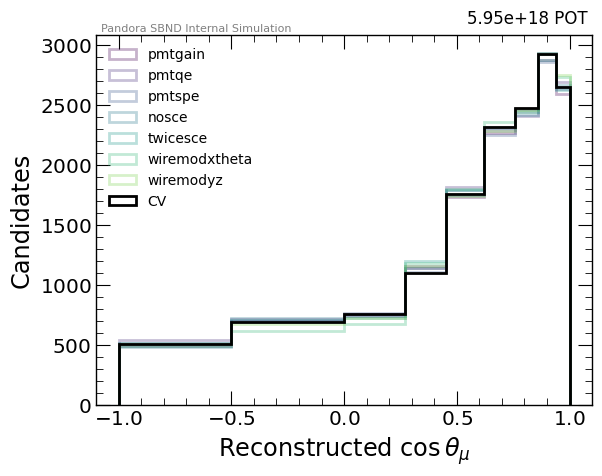

In [248]:
#Costheta
reco_costhetas_event_counts = []
rct_colors = plotters.get_colors('viridis',len(DET_VARS),max_color=0.8)
fig,ax = plt.subplots()
for i,rct in enumerate(reco_sel_costhetas):
  if i == len(DET_VARS):
    label = 'CV'
    color = 'black'
    alpha = 1.
  else:
    label = DET_VARS[i]
    color = rct_colors[i]
    alpha = 0.3
  c,_,_ = ax.hist(rct,bins=costheta_bins,weights=genweights_sel[i],label=label,histtype='step',alpha=alpha,color=color)
  reco_costhetas_event_counts.append(c)
ax.set_xlabel(r'Reconstructed $\cos\theta_\mu$')
ax.set_ylabel('Candidates')
ax.legend()
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
plotters.save_plot('reco_sel_sig_detsys_costheta_event_counts',fig=fig,folder_name=PLOT_DIR+'/det_var/')


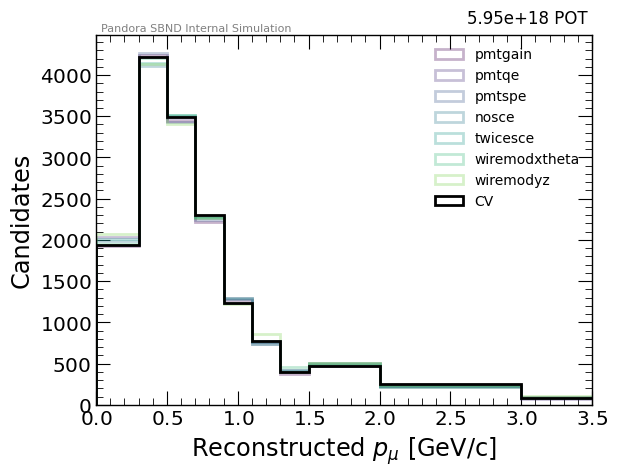

In [249]:
#Momentum
reco_moms_event_counts = []
fig,ax = plt.subplots()
mom_colors = plotters.get_colors('viridis',len(DET_VARS)-1,max_color=0.8)
for i,mom in enumerate(reco_sel_moms):
  if i == len(DET_VARS):
    label = 'CV'
    color = 'black'
    alpha = 1.
  else:
    label = DET_VARS[i]
    color = rct_colors[i]
    alpha = 0.3
  c,_,_ = ax.hist(mom,bins=momentum_bins,weights=genweights_sel[i],label=label,histtype='step',alpha=alpha,color=color)
  reco_moms_event_counts.append(c)
ax.set_xlabel(r'Reconstructed $p_\mu$ [GeV/c]')
ax.set_ylabel('Candidates')
ax.set_xlim(0,3.5)
ax.legend()
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
plotters.save_plot('reco_sel_sig_detsys_pmu_event_counts',fig=fig,folder_name=PLOT_DIR+'/det_var/')

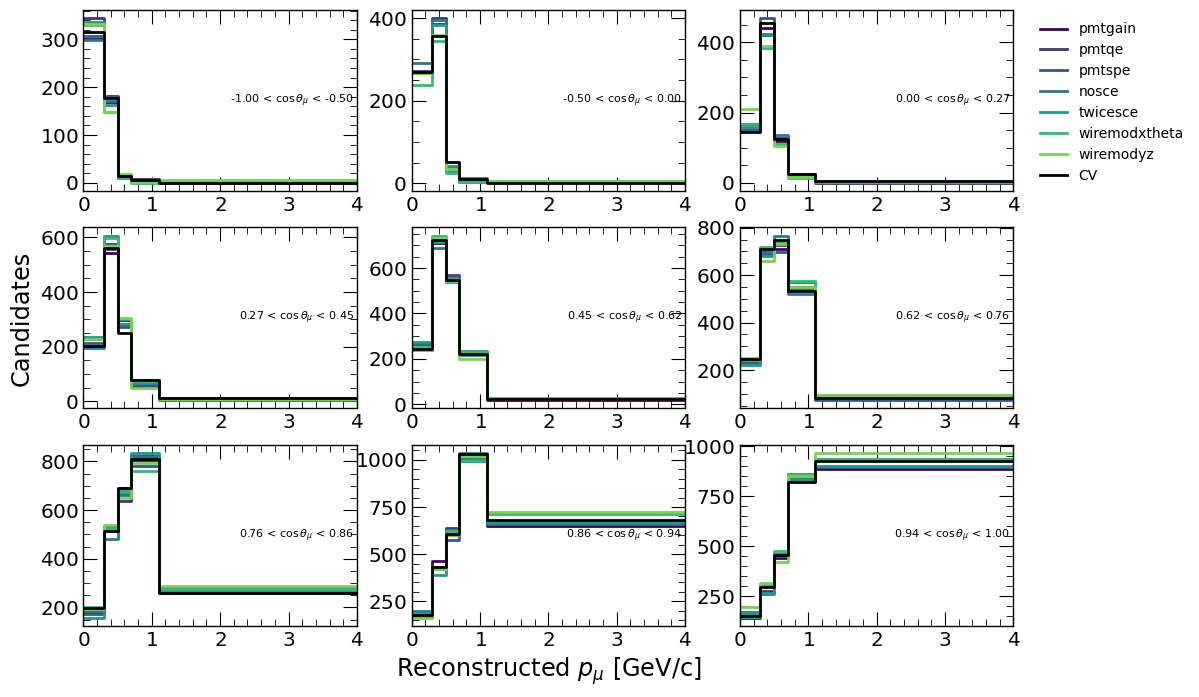

In [250]:
#2D binning
reco_2d_event_counts = []
fig,axs = None,None
differential_colors = plotters.get_colors('viridis',len(DET_VARS)-1,max_color=0.8)
for i,mom in enumerate(reco_sel_moms):
  if i == len(DET_VARS):
    label = 'CV'
    color = 'black'
    alpha = 1.
    legend = True
    add_labels = True
    xlabel = r'Reconstructed $p_\mu$ [GeV/c]'
  else:
    label = DET_VARS[i]
    color = rct_colors[i]
    alpha = 0.3
    legend = False
    add_labels = False
    xlabel = ''
  fig,axs = binning2d.plot_differential_hist(mom,reco_sel_costheta_bins[i],diff_momentum_bins,weights=genweights_sel[i],axs=axs,color=color,label=label,legend=legend,add_labels=add_labels,xlabel=xlabel)
  hist,_ = np.histogram(reco_sel_differential_bins[i],bins=differential_edges,weights=genweights_sel[i])
ax.set_xlabel(r'Reconstructed $p_\mu$ [GeV/c]')
ax.set_ylabel('Candidates')
#ax.legend()
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
plotters.save_plot('reco_sel_sig_detsys_2d_event_counts',fig=fig,folder_name=PLOT_DIR+'/det_var/')

## 3. Construct covariance matrix

In [307]:
from sbnd.cafclasses.systematics import Systematics

### 3.1 Build/Save

In [88]:
#Get the variables to initialize systematics
XSEC_UNIT = np.float64(np.loadtxt(f'{DATA_DIR}/data/2026_01_08/syst/metadata/xsec_unit.csv')) #Check this

In [319]:
csystematics = Systematics('costheta', costheta_bins, XSEC_UNIT,
  true_sig_costhetas[-1], true_sel_costhetas[-1], true_bg_costhetas[-1], reco_sel_costhetas[-1],
  reco_bg_costhetas[-1], genweights_sig[-1], genweights_sel[-1], genweights_sel_background[-1],
  keys=DET_VARS,stype='Det',pattern=None)

msystematics = Systematics('momentum', momentum_bins, XSEC_UNIT,
  true_sig_moms[-1], true_sel_moms[-1], true_bg_moms[-1], reco_sel_moms[-1],
  reco_bg_moms[-1], genweights_sig[-1], genweights_sel[-1], genweights_sel_background[-1],
  keys=DET_VARS,stype='Det',pattern=None)

dsystematics = Systematics('differential', differential_edges, XSEC_UNIT,
  true_sig_differential_bins[-1], true_sel_differential_bins[-1], true_bg_differential_bins[-1], reco_sel_differential_bins[-1],
  reco_bg_differential_bins[-1], genweights_sig[-1], genweights_sel[-1], genweights_sel_background[-1],
  keys=DET_VARS,stype='Det',pattern=None)


/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:178: RuntimeWarning: invalid value encountered in divide
  eff_truth = sel_truth / sig_truth


In [320]:
csystematics.process_det_systematics(true_sig_costhetas[:-1], true_sel_costhetas[:-1], true_bg_costhetas[:-1], reco_sel_costhetas[:-1], reco_bg_costhetas[:-1], genweights_sig[:-1], genweights_sel[:-1], genweights_sel_background[:-1])
msystematics.process_det_systematics(true_sig_moms[:-1], true_sel_moms[:-1], true_bg_moms[:-1], reco_sel_moms[:-1], reco_bg_moms[:-1], genweights_sig[:-1], genweights_sel[:-1], genweights_sel_background[:-1])
dsystematics.process_det_systematics(true_sig_differential_bins[:-1], true_sel_differential_bins[:-1], true_bg_differential_bins[:-1], reco_sel_differential_bins[:-1], reco_bg_differential_bins[:-1], genweights_sig[:-1], genweights_sel[:-1], genweights_sel_background[:-1])

7 goomba [00:00, 376.66 goomba/s]
7 goomba [00:00, 429.91 goomba/s]
7 goomba [00:00, 414.24 goomba/s]


In [321]:
for syst in [csystematics,msystematics,dsystematics]:
  syst.compute_covariances()
  syst.combine_summaries(summary_keys=['pds','tpc','sce'])


/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:35: RuntimeWarning: invalid value encountered in divide
  diff_fractional = diff / denom
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:74: RuntimeWarning: invalid value encountered in scalar divide
  correlation[i,j] = covariance_matrix[i,j] / (stds[i] * stds[j])
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:62: RuntimeWarning: invalid value encountered in divide
  fractional_uncertainty = stds / cv
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:82: RuntimeWarning: invalid value encountered in divide
  fractional_uncertainty = stds / cv


In [322]:
for s in [csystematics,msystematics,dsystematics]:
  s.save(save_dir=f'{DATA_DIR}/data/{day}/syst/',metadata_dir='metadata_detsys')

Saving 19 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_09/syst/


  0%|          | 0/10 [00:00<?, ? goomba/s]

100%|██████████| 10/10 [00:00<00:00, 22.51 goomba/s]


Saving 19 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_09/syst/


100%|██████████| 10/10 [00:00<00:00, 21.61 goomba/s]


Saving 19 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_09/syst/


100%|██████████| 10/10 [00:00<00:00, 20.04 goomba/s]


In [324]:
csystematics.systematics['sce']

{'cols': None,
 'col_names': None,
 'type': 'sce',
 'name': 'sce',
 'variation': None,
 'sigma_tilde': [],
 'sel': [],
 'xsec_cov': array([[ 5.13544402e-84, -6.83075351e-84,  7.45236283e-84,
         -1.01294587e-83, -5.20346434e-84,  4.98686431e-84,
          6.47520697e-84, -1.12152114e-83,  1.25566216e-83],
        [-6.83075351e-84,  9.84073085e-84, -5.06341243e-84,
          8.23849282e-84,  3.19296015e-84, -8.20527359e-85,
         -1.59378700e-83,  2.29715402e-83, -1.64004256e-83],
        [ 7.45236283e-84, -5.06341243e-84,  4.19583560e-83,
         -4.83209313e-83, -3.14961043e-83,  4.45685124e-83,
         -3.76491460e-83,  3.54520255e-83,  2.01573271e-83],
        [-1.01294587e-83,  8.23849282e-84, -4.83209313e-83,
          5.62761848e-83,  3.61136308e-83, -5.01381210e-83,
          3.80164055e-83, -3.37207641e-83, -2.68570580e-83],
        [-5.20346434e-84,  3.19296015e-84, -3.14961043e-83,
          3.61136308e-83,  2.36826371e-83, -3.37556187e-83,
          2.96103528e-83,

### 3.2 Load

In [294]:
csystematics_loaded = Systematics.from_saved(f'{DATA_DIR}/data/{day}/syst/',var_name='costheta',metadata_dir='metadata_detsys')
msystematics_loaded = Systematics.from_saved(f'{DATA_DIR}/data/{day}/syst/',var_name='momentum',metadata_dir='metadata_detsys')
dsystematics_loaded = Systematics.from_saved(f'{DATA_DIR}/data/{day}/syst/',var_name='differential',metadata_dir='metadata_detsys')

/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/cafclasses/systematics.py:1172: UserWarning: loadtxt: input contained no data: "/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_09/syst/tpc/costheta_sel.csv"
  arr_like = np.loadtxt(file_path)
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/cafclasses/systematics.py:1172: UserWarning: loadtxt: input contained no data: "/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_09/syst/tpc/momentum_sel.csv"
  arr_like = np.loadtxt(file_path)
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/cafclasses/systematics.py:1172: UserWarning: loadtxt: input contained no data: "/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_09/syst/tpc/differential_sel.csv"
  arr_like = np.loadtxt(file_path)
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_villa

Loaded 11 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_09/syst/
Loaded 11 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_09/syst/
Loaded 11 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_09/syst/


In [300]:
csystematics_loaded.systematics['det']

{'cols': None,
 'col_names': None,
 'type': 'det',
 'name': 'det',
 'variation': None,
 'sigma_tilde': array([], dtype=float64),
 'sel': array([], dtype=float64),
 'xsec_cov': array([[ 2.97029330e-82,  8.26672519e-83,  1.48860209e-82,
         -1.07680784e-82, -1.28900299e-82,  1.66081457e-82,
         -2.93747662e-82,  2.42545748e-82, -7.34538606e-83],
        [ 8.26672519e-83,  6.14172163e-83,  5.19664298e-83,
         -1.84886046e-83, -6.37501697e-83,  4.55382110e-83,
         -1.28045259e-82,  1.28539921e-82, -4.37151954e-83],
        [ 1.48860209e-82,  5.19664298e-83,  1.53432058e-82,
         -1.13169877e-82, -1.36824274e-82,  1.31096881e-82,
         -1.88814122e-82,  1.53595173e-82, -4.20817938e-83],
        [-1.07680784e-82, -1.84886046e-83, -1.13169877e-82,
          1.03101942e-82,  9.87241706e-83, -1.16272566e-82,
          1.45409008e-82, -1.11047464e-82,  1.66267609e-84],
        [-1.28900299e-82, -6.37501697e-83, -1.36824274e-82,
          9.87241706e-83,  1.62428595e-82

## 4. Plot systematics

In [297]:
label_y_shift = 0.0
summary_keys = ['pds','tpc','det']
for s,var_name in zip([csystematics,msystematics,dsystematics],['costheta','momentum','differential']):
  for unc_type in ['event','xsec']:
    if var_name == 'differential':
      bins = differential_edges
    elif var_name == 'costheta':
      bins = costheta_bins
    elif var_name == 'momentum':
      bins = momentum_bins
    #All systematics
    fig,ax,im = s.plot_event_rate_errs(f'{unc_type}',exclude_keys=summary_keys)
    plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
    plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
    plotters.save_plot(f'{var_name}_{unc_type}_errs_full', fig=fig, folder_name=f'{PLOT_DIR}/syst/det/fracunc')
    plt.close()

    fig,ax,im = s.plot_event_rate_errs(f'{unc_type}',include_keys=summary_keys+['stat'])
    plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
    plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
    plotters.save_plot(f'{var_name}_{unc_type}_errs_summary', fig=fig, folder_name=f'{PLOT_DIR}/syst/det/fracunc')
    plt.close()

In [298]:
for s in [csystematics,msystematics,dsystematics]:
  s.plot_all_covariance_matrices(plot_dir=f'{PLOT_DIR}/syst/det')

100%|██████████| 10/10 [00:27<00:00,  2.76s/ goomba]


## 5. Det syst as a function of cut

In [19]:
from sbnd.cafclasses.systematics import Systematics

In [20]:
COPY = False

In [21]:
#Get the variables to initialize systematics
XSEC_UNIT = np.float64(np.loadtxt(f'{DATA_DIR}/data/2026_01_08/syst/metadata/xsec_unit.csv')) #Check this

In [23]:
with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/calo_keys.txt', 'w') as f:
  for k in slcs[-1].data.keys():
    f.write(f'{k}\n')

In [25]:
slcs[-1].data.bin

costheta momentum differential
                                                            
                                                            
                                                            
                                                            
                                                            
                                                            
                                                            
__ntuple entry rec.slc..index                               
1        0     0                     4        4         36.0
               1                    -1       -1         -1.0
               2                    -1       -1         -1.0
               3                    -1       -1         -1.0
               4                    -1       -1         -1.0
..                                 ...      ...          ...
999      49    100002               -1       -1         -1.0
               100003               -1       -1         -1.0
               100004               -1       -1         -1.0
               100005               -1       -1         -1.0
               100006               -1       -1         -1.0

[6701653 rows x 3 columns]

In [ ]:
from time import time
cuts = []
#Only use copy for testing, afterwards use slcs since we only need it for this purpose
tc0 = time()
#Keep track of offbeam separately to get cosmic uncertainty
if COPY:
  _slcs = [slc.copy() for slc in slcs]
  _slc_slim = slc_slim.copy()
  _slc_sel_data = slc_data.copy()
  _slc_sel_offbeam = slc_offbeam.copy()
  _slc_sel_offbeam_data = slc_offbeam_data.copy()
else:
  _slcs = slcs
  _slc_slim = slc_slim
  _slc_sel_data = slc_data
  _slc_sel_offbeam = slc_offbeam
  _slc_sel_offbeam_data = slc_offbeam_data
tc1 = time()
print(f'Time to copy slices: {tc1-tc0:.2f} seconds')
#Set some binnings
BCFM_BINS = np.arange(0,1.1,0.025)
OPT0_BINS = (1/np.logspace(-7,1,140))[::-1] #Flip since opt0 is not inverted
NUSCORE_BINS = np.arange(-1,1.025,0.025)

from time import time

for cut in ['precut']+PAND_CUTS:
#for cut in ['muon']:
  print('*'*30,f' cut: {cut} ','*'*30)
  # At each cut, we want to...
  # 1. Apply cut
  # 2. Get selected events broken into signal and background.
  # 3. Get event rates for detector variations
  # 3.1. Detector variations
  # 3.2. Calo variations
  # 3.3. off beam in data/mc for cosmic uncertainty
  # 3.4. slim systematics
  # 4. Construct systematic objects
  # 5. Process systematics using stored values
  # 6. Combine into summary systematics
  # 7. Plot event rate with error bars overlayed
  # 8. Save systematics (into cut subfolder)

  # 0. Intiialize slices for storage
  _slcs_sel = [None]*(len(DET_FNAMES)+1)
  _slcs_sel_background = [None]*(len(DET_FNAMES)+1)
  _slcs_sel_calo = [None]*(len(CALO_VARS))
  _slcs_sel_background_calo = [None]*(len(CALO_VARS))
  subfolder = f'{DATA_DIR}/data/{day}/syst/{cut}'

  # 1. Apply cut
  t0 = time()
  if cut == 'muon':
    #Make a copy for calo variations, except the nominal which is already in _slcs
    _slcs_calo = [_slcs[-1].copy() for _ in range(len(CALO_VARS))]
    #For each calo variation, apply the cut
    for i,(s,calo_var) in enumerate(zip(_slcs_calo,CALO_VARS)):
      # Since we have offbeam combined, we need to process indices with the offbeam suffix with the nominal cut
      # Activate hyper-specific AI slop function
      s.cut_muon_by_offset(OFFBEAM_OFFSET,calo_var)
      #Remove suffix from calo variation
      # calo_cut_key = f'mu_{calo_var}.pfp.trk.is_muon_{calo_var}'
      # calo_cut_col = s.get_key(calo_cut_key)[0]
      # s.data = s.data[s.data[calo_cut_col] == True]
    #TEMPORARY bug fix
    print('TEMPORARY bug fix')
    for i,_slc in enumerate(_slcs):
      _slc.data = _slc.data[_slc.data.has_muon == True]
    _slc_sel_data.data = _slc_sel_data.data[_slc_sel_data.data.has_muon == True]
    _slc_sel_offbeam.data = _slc_sel_offbeam.data[_slc_sel_offbeam.data.has_muon == True]
    _slc_sel_offbeam_data.data = _slc_sel_offbeam_data.data[_slc_sel_offbeam_data.data.has_muon == True]
    _slc_slim.data = _slc_slim.data[_slc_slim.data.has_muon == True]
    print('TEMPORARY bug fix done')
  if cut != 'precut':
    [s.apply_cut(cut) for s in _slcs]
    _slc_sel_data.apply_cut(cut)
    _slc_sel_offbeam.apply_cut(cut)
    _slc_sel_offbeam_data.apply_cut(cut)
    _slc_slim.apply_cut(cut)
  #For the calo variations beyond muon, we just apply the nominal cut
  if cut in ['cosmic','lowz']:
    [s.apply_cut(cut) for s in _slcs_calo]
  t1 = time()
  print(f'Time to apply cut: {t1-t0:.2f} seconds')
  # 2. Get selected events broken into signal and background. Also just the signal events
  for i,slc in enumerate(_slcs):
    #Signal - filter using truth event type
    sig_mask = np.isin(slc.data.truth.event_type, [0,1])
    bg_mask = ~sig_mask
    #Selection - filter using cut.all column and has_muon
    _slcs_sel[i] = CAFSlice(slc.data[sig_mask], pot=slc.pot)
    #Background - filter using cut.all column, and is not signal has_muon
    _slcs_sel_background[i] = CAFSlice(slc.data[bg_mask], pot=slc.pot)
  if cut in ['muon','cosmic','lowz']:
    for i,slc in enumerate(_slcs_calo):
      #Signal - filter using truth event type
      sig_mask = np.isin(slc.data.truth.event_type, [0,1])
      bg_mask = ~sig_mask
      #Selection - filter using cut.all column and has_muon
      _slcs_sel_calo[i] = CAFSlice(slc.data[sig_mask], pot=slc.pot)
      _slcs_sel_background_calo[i] = CAFSlice(slc.data[bg_mask], pot=slc.pot)
  # sig_mask = np.isin(_slc_slim.data.truth.event_type, [0,1])
  # bg_mask = ~sig_mask
  # _slcs_sel_slim = CAFSlice(_slc_slim.data[sig_mask], pot=_slc_slim.pot)
  # _slcs_sel_background_slim = CAFSlice(_slc_slim.data[bg_mask], pot=_slc_slim.pot)
  t2 = time()
  print(f'Time to get selected events: {t2-t1:.2f} seconds')
  # 3. Get event rates for detector variations
  # 3.1 Detector variations
  #Get distribution after all cuts
  # - reco quantities
  # -- selected signal
  _reco_sel_costhetas = [s.data.mu.pfp.trk.costheta for s in _slcs_sel]
  _reco_sel_moms = [s.data.mu.pfp.trk.P.p_muon for s in _slcs_sel]
  _reco_sel_costheta_bins = [s.data.bin.costheta for s in _slcs_sel]
  _reco_sel_momentum_bins = [s.data.bin.momentum for s in _slcs_sel]
  _reco_sel_differential_bins = [s.data.bin.differential for s in _slcs_sel]

  # _reco_sel_costhetas_slim = slc_slim_sel.data.mu.pfp.trk.costheta
  # _reco_sel_moms_slim = slc_slim_sel.data.mu.pfp.trk.P.p_muon
  # _reco_sel_costheta_bins_slim = slc_slim_sel.data.bin.costheta
  # _reco_sel_momentum_bins_slim = slc_slim_sel.data.bin.momentum
  # _reco_sel_differential_bins_slim = slc_slim_sel.data.bin.differential
  # --- cut variables
  reco_sel_opt0 = [s.data.slc.opt0.score for s in _slcs_sel]
  reco_sel_bcfms = [s.data.slc.barycenterFM.score for s in _slcs_sel]
  reco_sel_nuscore = [s.data.slc.nu_score for s in _slcs_sel]

  # reco_sel_opt0_slim = slc_slim_sel.data.slc.opt0.score
  # reco_sel_bcfms_slim = slc_slim_sel.data.slc.barycenterFM.score
  # reco_sel_nuscore_slim = slc_slim_sel.data.slc.nu_score
  
  # -- background
  _reco_bg_costhetas = [s.data.mu.pfp.trk.costheta for s in _slcs_sel_background]
  _reco_bg_moms = [s.data.mu.pfp.trk.P.p_muon for s in _slcs_sel_background]
  _reco_bg_costheta_bins = [s.data.bin.costheta for s in _slcs_sel_background]
  _reco_bg_momentum_bins = [s.data.bin.momentum for s in _slcs_sel_background]
  _reco_bg_differential_bins = [s.data.bin.differential for s in _slcs_sel_background]

  # _reco_bg_costhetas_slim = slc_slim_sel_background.data.mu.pfp.trk.costheta
  # _reco_bg_moms_slim = slc_slim_sel_background.data.mu.pfp.trk.P.p_muon
  # _reco_bg_costheta_bins_slim = slc_slim_sel_background.data.bin.costheta
  # _reco_bg_momentum_bins_slim = slc_slim_sel_background.data.bin.momentum
  # _reco_bg_differential_bins_slim = slc_slim_sel_background.data.bin.differential
  # --- cut variables
  reco_bg_opt0 = [s.data.slc.opt0.score for s in _slcs_sel_background]
  reco_bg_bcfms = [s.data.slc.barycenterFM.score for s in _slcs_sel_background]
  reco_bg_nuscore = [s.data.slc.nu_score for s in _slcs_sel_background]

  # reco_bg_opt0_slim = slc_slim_sel_background.data.slc.opt0.score
  # reco_bg_bcfms_slim = slc_slim_sel_background.data.slc.barycenterFM.score
  # reco_bg_nuscore_slim = slc_slim_sel_background.data.slc.nu_score
  # - true quantities
  # -- selected signal
  _true_sel_costhetas = [s.data.truth.mu.dir.z for s in _slcs_sel]
  _true_sel_moms = [s.data.truth.mu.totp for s in _slcs_sel]
  _true_sel_costheta_bins = [s.data.true_bin.costheta for s in _slcs_sel]
  _true_sel_momentum_bins = [s.data.true_bin.momentum for s in _slcs_sel]
  _true_sel_differential_bins = [s.data.true_bin.differential for s in _slcs_sel]
  #Fix the costheta for selected slices that don't have a true muon
  masks = [tct == -1 for tct in _true_sel_costhetas]
  for i,(mask,s) in enumerate(zip(masks,_slcs_sel)):
    if not any(mask): continue
    _true_sel_costhetas[i][mask] = s.data.mu.pfp.trk.truth.p.dir.z[mask]
  #Fix the momentum for selected slices that don't have a true muon
  masks = [tm == -1 for tm in _true_sel_moms]
  for i,(mask,s) in enumerate(zip(masks,_slcs_sel)):
    if not any(mask): continue
    _true_sel_moms[i][mask] = s.data.mu.pfp.trk.P.p_muon[mask]

  # _true_sel_costhetas_slim = slc_slim_sel.data.truth.mu.dir.z
  # _true_sel_moms_slim = slc_slim_sel.data.truth.mu.totp
  # _true_sel_costheta_bins_slim = slc_slim_sel.data.true_bin.costheta
  # _true_sel_momentum_bins_slim = slc_slim_sel.data.true_bin.momentum
  # _true_sel_differential_bins_slim = slc_slim_sel.data.true_bin.differential
  #Fix the costheta for selected slices that don't have a true muon
  # mask = _true_sel_costhetas_slim == -1
  # _true_sel_costhetas_slim[mask] = slc_slim_sel.data.mu.pfp.trk.truth.p.dir.z[mask]
  # #Fix the momentum for selected slices that don't have a true muon
  # mask = _true_sel_moms_slim == -1
  # _true_sel_moms_slim[mask] = slc_slim_sel.data.mu.pfp.trk.P.p_muon[mask]

  # # -- background
  _true_bg_costhetas = [s.data.truth.mu.dir.z for s in _slcs_sel_background]
  _true_bg_moms = [s.data.truth.mu.totp for s in _slcs_sel_background]
  _true_bg_costheta_bins = [s.data.true_bin.costheta for s in _slcs_sel_background]
  _true_bg_momentum_bins = [s.data.true_bin.momentum for s in _slcs_sel_background]
  _true_bg_differential_bins = [s.data.true_bin.differential for s in _slcs_sel_background]
  # #Fix the costheta for selected slices that don't have a true muon
  masks = [tct == -1 for tct in _true_bg_costhetas]
  for i,(mask,s) in enumerate(zip(masks,_slcs_sel_background)):
    if not any(mask): continue
    _true_bg_costhetas[i][mask] = s.data.mu.pfp.trk.truth.p.dir.z[mask]
  #Fix the momentum for selected slices that don't have a true muon
  masks = [tm == -1 for tm in _true_bg_moms]
  for i,(mask,s) in enumerate(zip(masks,_slcs_sel_background)):
    if not any(mask): continue
    _true_bg_moms[i][mask] = s.data.mu.pfp.trk.P.p_muon[mask]

  # _true_bg_costhetas_slim = slc_slim_sel_background.data.truth.mu.dir.z
  # _true_bg_moms_slim = slc_slim_sel_background.data.truth.mu.totp
  # _true_bg_costheta_bins_slim = slc_slim_sel_background.data.true_bin.costheta
  # _true_bg_momentum_bins_slim = slc_slim_sel_background.data.true_bin.momentum
  # _true_bg_differential_bins_slim = slc_slim_sel_background.data.true_bin.differential
  #Fix the costheta for selected slices that don't have a true muon
  # mask = _true_bg_costhetas_slim == -1
  # _true_bg_costhetas_slim[mask] = slc_slim_sel_background.data.mu.pfp.trk.truth.p.dir.z[mask]
  # #Fix the momentum for selected slices that don't have a true muon
  # mask = _true_bg_moms_slim == -1
  # _true_bg_moms_slim[mask] = slc_slim_sel_background.data.mu.pfp.trk.P.p_muon[mask]
  

  # Genweights
  _genweights_sel_background = [s.data.genweight for s in _slcs_sel_background]
  _genweights_sel = [s.data.genweight for s in _slcs_sel]
  _genweights_sel_slim = slc_slim_sel.data.genweight
  _genweights_sel_background_slim = slc_slim_sel_background.data.genweight

  # 3.2 Calo variations
  if cut in ['muon','cosmic','lowz']:
    # - reco quantities
    # -- selected signal
    _reco_sel_costhetas_calo = [s.data.mu.pfp.trk.costheta for s in _slcs_sel_calo]
    _reco_sel_moms_calo = [s.data.mu.pfp.trk.P.p_muon for s in _slcs_sel_calo]
    _reco_sel_differential_bins_calo = [s.data.bin.differential for s in _slcs_sel_calo]
    # --- cut variables
    reco_sel_opt0_calo = [s.data.slc.opt0.score for s in _slcs_sel_calo]
    reco_sel_bcfms_calo = [s.data.slc.barycenterFM.score for s in _slcs_sel_calo]
    reco_sel_nuscore_calo = [s.data.slc.nu_score for s in _slcs_sel_calo]
    # -- background
    _reco_bg_costhetas_calo = [s.data.mu.pfp.trk.costheta for s in _slcs_sel_background_calo]
    _reco_bg_moms_calo = [s.data.mu.pfp.trk.P.p_muon for s in _slcs_sel_background_calo]
    _reco_bg_differential_bins_calo = [s.data.bin.differential for s in _slcs_sel_background_calo]
    # --- cut variables
    reco_bg_opt0_calo = [s.data.slc.opt0.score for s in _slcs_sel_background_calo]
    reco_bg_bcfms_calo = [s.data.slc.barycenterFM.score for s in _slcs_sel_background_calo]
    reco_bg_nuscore_calo = [s.data.slc.nu_score for s in _slcs_sel_background_calo]
    # - true quantities
    # -- selected signal
    _true_sel_costhetas_calo = [s.data.truth.mu.dir.z for s in _slcs_sel_calo]
    _true_sel_moms_calo = [s.data.truth.mu.totp for s in _slcs_sel_calo]
    _true_sel_differential_bins_calo = [s.data.true_bin.differential for s in _slcs_sel_calo]
    # -- background
    _true_bg_costhetas_calo = [s.data.truth.mu.dir.z for s in _slcs_sel_background_calo]
    _true_bg_moms_calo = [s.data.truth.mu.totp for s in _slcs_sel_background_calo]
    _true_bg_differential_bins_calo = [s.data.true_bin.differential for s in _slcs_sel_background_calo]

    # Genweights
    _genweights_sel_background_calo = [s.data.genweight for s in _slcs_sel_background_calo]
    _genweights_sel_calo = [s.data.genweight for s in _slcs_sel_calo]

  # 3.3 Off beam in data/mc for cosmic uncertainty
  # - reco quantities
  # -- selected 
  _reco_sel_costhetas_offbeam = [s.data.mu.pfp.trk.costheta for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]
  _reco_sel_moms_offbeam = [s.data.mu.pfp.trk.P.p_muon for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]
  _reco_sel_costheta_bins_offbeam = [s.data.bin.costheta for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]
  _reco_sel_momentum_bins_offbeam = [s.data.bin.momentum for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]
  _reco_sel_differential_bins_offbeam = [s.data.bin.differential for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]
  # --- cut variables
  reco_sel_opt0_offbeam = [s.data.slc.opt0.score for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]
  reco_sel_bcfms_offbeam = [s.data.slc.barycenterFM.score for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]
  reco_sel_nuscore_offbeam = [s.data.slc.nu_score for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]

  #Genweights
  _genweights_sel_offbeam = [s.data.genweight for s in [_slc_sel_offbeam,_slc_sel_offbeam_data]]
  
  t3 = time()
  print(f'Time to extract reco/true quantities: {t3-t2:.2f} seconds')
  # 4. Construct systematic objects
  _csystematics = Systematics('costheta', costheta_bins, _reco_sel_costhetas[-1],
    _reco_bg_costhetas[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_background[-1],
    xsec_unit=XSEC_UNIT,
    true_sig=true_sig_costhetas[-1],
    true_sel=_true_sel_costhetas[-1],
    true_sel_background=_true_bg_costhetas[-1], keys=DET_VARS+CALO_VARS,stype='Det',pattern=None)
  _msystematics = Systematics('momentum', momentum_bins, _reco_sel_moms[-1],
    _reco_bg_moms[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_background[-1],
    xsec_unit=XSEC_UNIT,
    true_sig=true_sig_moms[-1],
    true_sel=_true_sel_moms[-1],
    true_sel_background=_true_bg_moms[-1], keys=DET_VARS+CALO_VARS,stype='Det',pattern=None)
  _dsystematics = Systematics('differential', differential_edges, _reco_sel_differential_bins[-1],
    _reco_bg_differential_bins[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_background[-1],
    xsec_unit=XSEC_UNIT,
    true_sig=true_sig_differential_bins[-1],
    true_sel=_true_sel_differential_bins[-1],
    true_sel_background=_true_bg_differential_bins[-1], keys=DET_VARS+CALO_VARS,stype='Det',pattern=None)

  _opt0systematics = Systematics('opt0', OPT0_BINS,
    reco_sel_opt0[-1], reco_bg_opt0[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_background[-1],
    keys=DET_VARS+CALO_VARS,stype='Det',pattern=None)
  _bcfmsystematics = Systematics('bcfm', BCFM_BINS,
    reco_sel_bcfms[-1], reco_bg_bcfms[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_background[-1],
    keys=DET_VARS+CALO_VARS,stype='Det',pattern=None)
  _nusystematics = Systematics('nuscore', NUSCORE_BINS,
    reco_sel_nuscore[-1], reco_bg_nuscore[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_background[-1],
    keys=DET_VARS+CALO_VARS,stype='Det',pattern=None)

  # Process separates systematics for cosmic uncertainty - there is no selected signal, everything is background.
  _csystematics_cosmic = Systematics('costheta', costheta_bins,
    _reco_sel_costhetas[-1],_reco_sel_costhetas_offbeam[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_offbeam[-1],
    xsec_unit=XSEC_UNIT,
    keys=['cosmic'],stype='Cosmic',pattern=None)
  _msystematics_cosmic = Systematics('momentum', momentum_bins,
    _reco_sel_moms[-1],_reco_sel_moms_offbeam[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_offbeam[-1],
    xsec_unit=XSEC_UNIT,
    keys=['cosmic'],stype='Cosmic',pattern=None)
  _dsystematics_cosmic = Systematics('differential', differential_edges,
    _reco_sel_differential_bins[-1],_reco_sel_differential_bins_offbeam[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_offbeam[-1],
    xsec_unit=XSEC_UNIT,
    keys=['cosmic'],stype='Cosmic',pattern=None)

  _opt0systematics_cosmic = Systematics('opt0', OPT0_BINS,
    reco_sel_opt0[-1], reco_sel_opt0_offbeam[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_offbeam[-1],
    xsec_unit=XSEC_UNIT,
    keys=['cosmic'],stype='Cosmic',pattern=None)
  _bcfmsystematics_cosmic = Systematics('bcfm', BCFM_BINS,
    reco_sel_bcfms[-1], reco_sel_bcfms_offbeam[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_offbeam[-1],
    keys=['cosmic'],stype='Cosmic',pattern=None)
  _nusystematics_cosmic = Systematics('nuscore', NUSCORE_BINS,
    reco_sel_nuscore[-1], reco_sel_nuscore_offbeam[-1], genweights_sig[-1], _genweights_sel[-1], _genweights_sel_offbeam[-1],
    keys=['cosmic'],stype='Cosmic',pattern=None)

  # Slim systematics
  # _csystematics_slim = Systematics('costheta', costheta_bins, _reco_sel_costhetas_slim,
  #   _reco_bg_costhetas_slim, genweights_sig_slim, _genweights_sel_slim, _genweights_sel_background_slim,
  #   xsec_unit=XSEC_UNIT,
  #   true_sig=true_sig_slim,
  #   true_sel=_true_sel_costhetas_slim,
  #   true_sel_background=_true_bg_costhetas_slim,stype='RW')
  
  t4 = time()
  print(f'Time to construct systematic objects: {t4-t3:.2f} seconds')
  # 5. Process systematics using stored values
  # 5.1. Detector variations
  _csystematics.process_det_systematics(_reco_sel_costhetas[:-1],_reco_bg_costhetas[:-1],_genweights_sel[:-1],_genweights_sel_background[:-1],
    true_sig_vars=_true_sel_costhetas[:-1],
    true_sel_vars=_true_sel_costhetas[:-1],
    true_sel_background_vars=_true_bg_costhetas[:-1],sys_names=DET_VARS)
  _msystematics.process_det_systematics(_reco_sel_moms[:-1],_reco_bg_moms[:-1],_genweights_sel[:-1],_genweights_sel_background[:-1],
    true_sig_vars=_true_sel_moms[:-1],
    true_sel_vars=_true_sel_moms[:-1],
    true_sel_background_vars=_true_bg_moms[:-1],sys_names=DET_VARS)
  _dsystematics.process_det_systematics(_reco_sel_differential_bins[:-1],_reco_bg_differential_bins[:-1],_genweights_sel[:-1],_genweights_sel_background[:-1],
    true_sig_vars=_true_sel_differential_bins[:-1],
    true_sel_vars=_true_sel_differential_bins[:-1],
    true_sel_background_vars=_true_bg_differential_bins[:-1],sys_names=DET_VARS)

  _opt0systematics.process_det_systematics(reco_sel_opt0[:-1], reco_bg_opt0[:-1],  _genweights_sel[:-1], _genweights_sel_background[:-1],sys_names=DET_VARS)
  _bcfmsystematics.process_det_systematics(reco_sel_bcfms[:-1], reco_bg_bcfms[:-1],  _genweights_sel[:-1], _genweights_sel_background[:-1],sys_names=DET_VARS)
  _nusystematics.process_det_systematics(reco_sel_nuscore[:-1], reco_bg_nuscore[:-1],  _genweights_sel[:-1], _genweights_sel_background[:-1],sys_names=DET_VARS)
  # 5.2. Calo variations
  if cut in ['muon','cosmic','lowz']:
    _csystematics.process_det_systematics(_reco_sel_costhetas_calo,_reco_bg_costhetas_calo,_genweights_sel_calo,_genweights_sel_background_calo,
      true_sig_vars=_true_sel_costhetas_calo,
      true_sel_vars=_true_sel_costhetas_calo,
      true_sel_background_vars=_true_bg_costhetas_calo,
      sys_names=CALO_VARS)
    _msystematics.process_det_systematics(_reco_sel_moms_calo,_reco_bg_moms_calo,_genweights_sel_calo,_genweights_sel_background_calo,
      true_sig_vars=_true_sel_moms_calo,
      true_sel_vars=_true_sel_moms_calo,
      true_sel_background_vars=_true_bg_moms_calo,
      sys_names=CALO_VARS)
    _dsystematics.process_det_systematics(_reco_sel_differential_bins_calo,_reco_bg_differential_bins_calo,_genweights_sel_calo,_genweights_sel_background_calo,
      true_sig_vars=_true_sel_differential_bins_calo,
      true_sel_vars=_true_sel_differential_bins_calo,
      true_sel_background_vars=_true_bg_differential_bins_calo,
      sys_names=CALO_VARS)

    _opt0systematics.process_det_systematics(reco_sel_opt0_calo, reco_bg_opt0_calo,  _genweights_sel_calo, _genweights_sel_background_calo,
      sys_names=CALO_VARS)
    _bcfmsystematics.process_det_systematics(reco_sel_bcfms_calo, reco_bg_bcfms_calo,  _genweights_sel_calo, _genweights_sel_background_calo,
      sys_names=CALO_VARS)
    _nusystematics.process_det_systematics(reco_sel_nuscore_calo, reco_bg_nuscore_calo,  _genweights_sel_calo, _genweights_sel_background_calo,
      sys_names=CALO_VARS)
    proc_keys = DET_VARS+CALO_VARS
  else:
    proc_keys = DET_VARS
  # 5.3. Off beam in data/mc for cosmic uncertainty - We use the CV as the selected signal, and the offbeam MC as the background. This way we get a properly scaled uncertainty.
  _csystematics_cosmic.process_det_systematics([_reco_sel_costhetas[-1]], [_reco_sel_costhetas_offbeam[0]], [_genweights_sel[-1]], [_genweights_sel_offbeam[0]],sys_names=['cosmic'])
  _msystematics_cosmic.process_det_systematics([_reco_sel_moms[-1]], [_reco_sel_moms_offbeam[0]], [_genweights_sel[-1]], [_genweights_sel_offbeam[0]],sys_names=['cosmic'])
  _dsystematics_cosmic.process_det_systematics([_reco_sel_differential_bins[-1]], [_reco_sel_differential_bins_offbeam[0]], [_genweights_sel[-1]], [_genweights_sel_offbeam[0]],sys_names=['cosmic'])
  _opt0systematics_cosmic.process_det_systematics([reco_sel_opt0[-1]], [reco_sel_opt0_offbeam[0]], [_genweights_sel[-1]], [_genweights_sel_offbeam[0]],sys_names=['cosmic'])
  _bcfmsystematics_cosmic.process_det_systematics([reco_sel_bcfms[-1]], [reco_sel_bcfms_offbeam[0]], [_genweights_sel[-1]], [_genweights_sel_offbeam[0]],sys_names=['cosmic'])
  _nusystematics_cosmic.process_det_systematics([reco_sel_nuscore[-1]], [reco_sel_nuscore_offbeam[0]], [_genweights_sel[-1]], [_genweights_sel_offbeam[0]],sys_names=['cosmic'])

  # 5.4. Compute covariances before combining
  for syst in [_csystematics,_msystematics,_dsystematics,_opt0systematics,_bcfmsystematics,_nusystematics]:
    syst.compute_covariances(keys=proc_keys)
  for syst in [_csystematics_cosmic,_msystematics_cosmic,_dsystematics_cosmic,_opt0systematics_cosmic,_bcfmsystematics_cosmic,_nusystematics_cosmic]:
    syst.compute_covariances(keys=['cosmic'])

  # 5.5. Combine into single systematic object - store the cosmic data
  _csystematics.combine(_csystematics_cosmic,store_other=True,other_name='cosmic_data')
  _msystematics.combine(_msystematics_cosmic,store_other=True,other_name='cosmic_data')
  _dsystematics.combine(_dsystematics_cosmic,store_other=True,other_name='cosmic_data')
  _opt0systematics.combine(_opt0systematics_cosmic,store_other=True,other_name='cosmic_data')
  _bcfmsystematics.combine(_bcfmsystematics_cosmic,store_other=True,other_name='cosmic_data')
  _nusystematics.combine(_nusystematics_cosmic,store_other=True,other_name='cosmic_data')
  t5 = time()
  print(f'Time to process systematics: {t5-t4:.2f} seconds')
  # 6. Get summary systematics and save
  for qq,syst in enumerate([_csystematics,_msystematics,_dsystematics,_opt0systematics,_bcfmsystematics,_nusystematics]):
    #print(f'Processing systematic {qq}')
    #syst.compute_covariances(keys=proc_keys)
    syst.combine_summaries(summary_keys=['pds','tpc','sce','calo','total'])
    syst.save(save_dir=subfolder,metadata_dir='metadata_detsys')
  t6 = time()
  print(f'Time to combine/save systematics: {t6-t5:.2f} seconds')
  #break
  # 7. Plots
  # 7.1 Plot event rate with error bars overlayed
  label_y_shift = 0.0
  summary_keys = ['total','pds','tpc','sce','calo','cosmic']
  subfolder_plot = f'{PLOT_DIR}/{cut}/fracunc'
  subfolder_dist = f'{PLOT_DIR}/{cut}/dist'
  subfolder_cov = f'{PLOT_DIR}/{cut}/twod'
  for s,var_name in zip([_csystematics,_msystematics,_dsystematics,_opt0systematics,_bcfmsystematics,_nusystematics],['costheta','momentum','differential','opt0','bcfm','nuscore']):
    for unc_type in ['event','xsec']:
      if var_name == 'differential':
        bins = differential_edges
      elif var_name == 'costheta':
        bins = costheta_bins
      elif var_name == 'momentum':
        bins = momentum_bins
      if var_name in ['opt0','bcfm','nuscore'] and unc_type == 'xsec':
        continue
      #print(f'unc_type: {unc_type}, var_name: {var_name}')
      #All systematics
      fig,ax,im = s.plot_event_rate_errs(f'{unc_type}',exclude_keys=summary_keys[:-1])
      plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
      plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
      plotters.save_plot(f'{var_name}_{unc_type}_errs_full', fig=fig, folder_name=subfolder_plot)
      plt.close()

      fig,ax,im = s.plot_event_rate_errs(f'{unc_type}',include_keys=summary_keys+['stat'])
      plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
      plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
      plotters.save_plot(f'{var_name}_{unc_type}_errs_summary', fig=fig, folder_name=subfolder_plot)
      plt.close()
      
    # 7.2 Plot universes
    figs = s.plot_all_distributions(plot_key='sel',exclude_keys=['cosmic'],plot_dir=subfolder_dist,save_plots=True)
    figs = s.plot_all_distributions(plot_key='sigma_tilde',exclude_keys=['cosmic'],plot_dir=subfolder_dist,save_plots=True)

    # Plot covariance matrices
    #s.plot_all_covariance_matrices(plot_dir=subfolder_cov,save_plots=True,progress_bar=True)

  for s in [_csystematics_cosmic,_msystematics_cosmic,_dsystematics_cosmic,_opt0systematics_cosmic,_bcfmsystematics_cosmic,_nusystematics_cosmic]:
    figs = s.plot_all_distributions(plot_key='sel',keys=['cosmic'],plot_dir=subfolder_dist,save_plots=True)
    figs = s.plot_all_distributions(plot_key='sigma_tilde',keys=['cosmic'],plot_dir=subfolder_dist,save_plots=True)
  
  t7 = time()
  print(f'Time to plot systematics: {t7-t6:.2f} seconds')
  #break

Time to copy slices: 0.00 seconds
******************************  cut: precut  ******************************
Time to apply cut: 0.00 seconds


## Testing

In [32]:
hdr = pd.read_hdf(f'{DATA_DIR}/{MC_FNAME}',key='hdr_0')

In [26]:
hdr.pot.sum()

1.5086108e+18